# ENGINEERING CONTEXT:
You are building a tunnel in the Himalayas.
The Geotechnical Baseline Report (GBR) assumed Class III rock (Good).
Your team drilled 20 holes. 14 showed Class III. 6 showed Class IV (Poor).
Question: What is the TRUE probability of encountering Class III?

*basically coin_flip applied with eng vocab*



c:\Users\digit\miniconda3\envs\infra_quant\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.


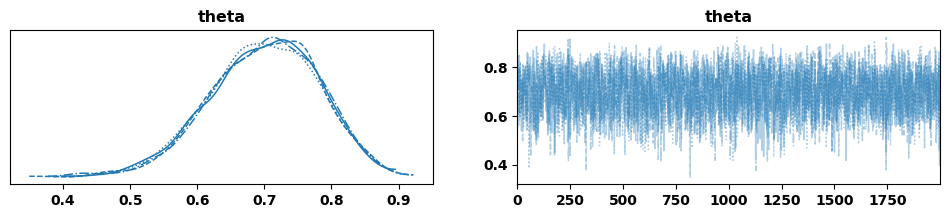

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az



tests=20
c3=14

with pm.Model() as rock_model:
    theta = pm.Beta("theta", alpha = 7, beta = 3) # -> gbr said to err on the side of 'good' rocks = class3

    likelihood = pm.Binomial("likelihood", n=tests, p=theta, observed=c3) #type:ignore
    trace = pm.sample(2000, random_seed=42, core=2, tune=1000)
    az.plot_trace(trace)
    plt.show()
    #~0.73 peakage


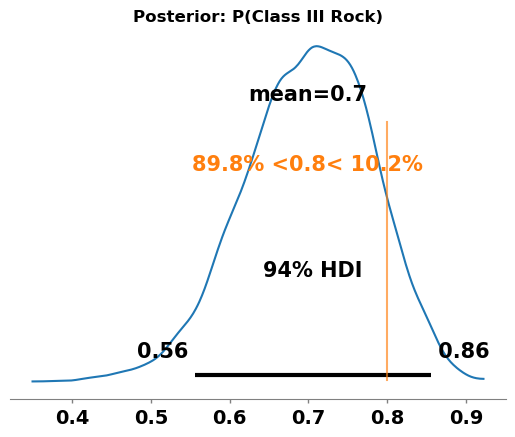

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
theta  0.699  0.081   0.556    0.855      0.001    0.001    3250.0    4958.0   

       r_hat  
theta    1.0  


In [7]:
az.plot_posterior(trace, var_names=["theta"], ref_val=0.80)
plt.title("Posterior: P(Class III Rock)")
plt.show()

# The ref_val is strictly defined by the Contract (Clause 4.12 base assumption).
# If the contract priced the tunnel assuming 80% Class III, ref_val = 0.80
print(az.summary(trace, var_names=["theta"]))


# the graph draws line at x=0.8 and the percentage is how much of the lue line area is to the left/right

# on the x axis that c3 rock, its the percentage of the mountain that is good
# the area is how strongly we believe the moutain matches specific x values
# since about 90% is to the left of the ref value, the reality is grim then we imagined it to be

In [ ]:
# FIDIC 4.12 Question: Is the rock WORSE than the GBR predicted?
posterior_samples = trace.posterior["theta"].values.flatten() #type:ignore
# into a single massive 1d array, we just want value of 2*2000

# Probability that the true Class III percentage is BELOW the GBR assumption (80%)
prob_worse_than_gbr = (posterior_samples < 0.80).mean()
print(f"P(Worse than GBR): {prob_worse_than_gbr * 100:.1f}%")

# If this is > 50%, the Contractor has a FIDIC 4.12 argument.
if prob_worse_than_gbr > 0.50:
    print("⚠️ WARNING: Bayesian evidence supports Clause 4.12 claim.")
else:
    print("✅ Rock conditions are consistent with the GBR.")

# Procedural variation: compute risk from raw array instead of visualizer

P(Worse than GBR): 89.8%
⚠️ WARNING: Bayesian evidence supports Clause 4.12 claim.


array([0.77302966, 0.77302966, 0.78650212, ..., 0.62284361, 0.67103282,
       0.67103282], shape=(8000,))